In [1]:
#importing require python classes and packages
import pandas as pd
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow.keras.utils import to_categorical
import pickle
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Input
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import  MaxPooling2D
from tensorflow.keras.layers import Convolution2D
from sklearn.preprocessing import StandardScaler
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

C:\Users\sravi\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [2]:
#defining & initialization AdaBelief optimizer algorithm
opt = tfa.optimizers.AdaBelief(learning_rate=0.01)
print("AdaBelief Initialization Completed")

AdaBelief Initialization Completed


In [3]:
#loading & displaying dataset1 which contains combination of 4 different heart datasets
dataset = pd.read_csv("Dataset/Cleveland_Hungary_Switzerland_LongBeach.csv")
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [4]:
#finding and displaying count of missing or null values
dataset.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

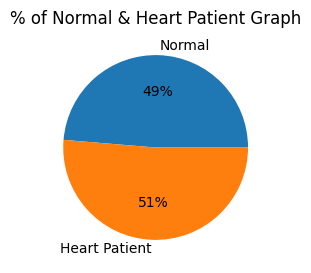

In [5]:
#analysing & visualizing different number of normal and heart patients records found in dataset
#graphs of different weather condition found in dataset
patients = dataset['target'].ravel() #extracting weather data
labels, count = np.unique(patients, return_counts=True)
labels = ['Normal', 'Heart Patient']
plt.figure(figsize=(4, 3))
plt.pie(count, labels = labels, autopct='%.0f%%')
plt.title("% of Normal & Heart Patient Graph")
plt.show() 

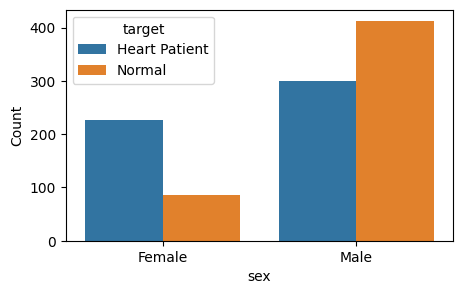

In [6]:
#visualizing & analysing number of healthy & heart patient graph gender wise
gender = dataset.groupby(['sex'])['target'].value_counts().reset_index(name="Count")
gender.loc[gender["sex"] == 0, "sex"] = "Female"
gender.loc[gender["sex"] == 1, "sex"] = "Male"
gender.loc[gender["target"] == 0, "target"] = "Normal"
gender.loc[gender["target"] == 1, "target"] = "Heart Patient"
plt.figure(figsize=(5, 3))
sns.barplot(data=gender, x="sex", y="Count", hue="target")
plt.show()

In [7]:
#normalizing training features
Y = dataset['target'].ravel()
dataset.drop(['target'], axis = 1,inplace=True)
X = dataset.values
#using standard scaler for normalization
scaler = StandardScaler()
X = scaler.fit_transform(X)
print("Normalized Features = "+str(X))

Normalized Features = [[-0.26843658  0.66150409 -0.91575542 ...  0.99543334  1.20922066
   1.08985168]
 [-0.15815703  0.66150409 -0.91575542 ... -2.24367514 -0.73197147
   1.08985168]
 [ 1.71659547  0.66150409 -0.91575542 ... -2.24367514 -0.73197147
   1.08985168]
 ...
 [-0.81983438  0.66150409 -0.91575542 ... -0.6241209   0.23862459
  -0.52212231]
 [-0.4889957  -1.51170646 -0.91575542 ...  0.99543334 -0.73197147
  -0.52212231]
 [-0.04787747  0.66150409 -0.91575542 ... -0.6241209   0.23862459
   1.08985168]]


In [8]:
#split dataset into train and test
X = np.reshape(X, (X.shape[0], X.shape[1], 1, 1))
Y = to_categorical(Y)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2)
print("Total records found in dataset : "+str(X.shape[0]))
print("Total features found in dataset : "+str(X.shape[1]))
print("80% dataset for training : "+str(X_train.shape[0]))
print("20% dataset for testing  : "+str(X_test.shape[0]))

Total records found in dataset : 1025
Total features found in dataset : 13
80% dataset for training : 820
20% dataset for testing  : 205


In [9]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [10]:
#function to calculate all metrics
def calculateMetrics(algorithm, testY, predict):
    labels = ['Normal', 'Heart Patient']
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 3))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(labels)])
    axs[0].set_title(algorithm+" Confusion matrix")
    random_probs = [0 for i in range(len(testY))]
    p_fpr, p_tpr, _ = roc_curve(testY, random_probs, pos_label=1)
    plt.plot(p_fpr, p_tpr, linestyle='--', color='orange',label="True classes")
    ns_fpr, ns_tpr, _ = roc_curve(testY, predict, pos_label=1)
    axs[1].plot(ns_fpr, ns_tpr, linestyle='--', label='Predicted Classes')
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    plt.show()

7/7 [==============================] - 0s 1ms/step
Dataset1 CNN2D with AdaBelief Accuracy  : 99.02439024390245
Dataset1 CNN2D with AdaBelief Precision : 99.02912621359224
Dataset1 CNN2D with AdaBelief Recall    : 99.03846153846155
Dataset1 CNN2D with AdaBelief FSCORE    : 99.02436702836475


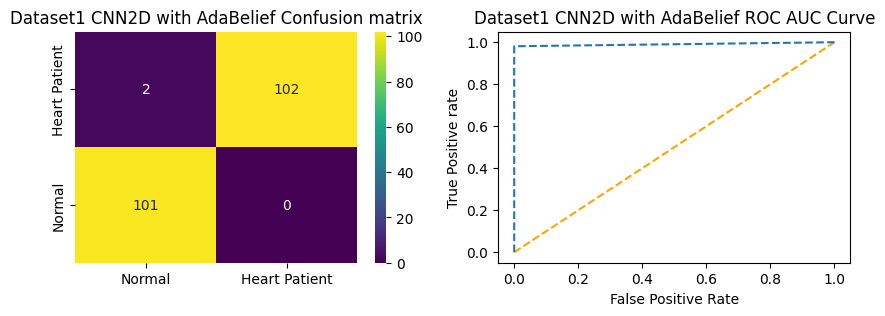

In [11]:
#create CNN model object
ada_model1 = Sequential()
#adding CNN layer with 32 neurons for data optimizations and filteration 
ada_model1.add(Convolution2D(32, (1, 1), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
#max layer to collect relevant data from CNN layer and ignore irrelevant features
ada_model1.add(MaxPooling2D(pool_size = (1, 1)))
#defining another CNN layer for further data optimizations
ada_model1.add(Convolution2D(32, (1, 1), activation = 'relu'))
ada_model1.add(MaxPooling2D(pool_size = (1, 1)))
ada_model1.add(Flatten())
#defining output layer
ada_model1.add(Dense(units = 256, activation = 'relu'))
ada_model1.add(Dense(units = y_train.shape[1], activation='softmax'))
#compile and train the model using adabelief optimizer
ada_model1.compile(optimizer = opt, loss='categorical_crossentropy', metrics=['accuracy'])
if os.path.exists('model/cleveland_ada_weights.hdf5') == False:
    model_check_point = ModelCheckpoint(filepath='model/cleveland_ada_weights.hdf5', verbose = 1, save_best_only = True)
    hist = ada_model1.fit(X_train, y_train, epochs = 15, batch_size = 8, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/cleveland_ada_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()
else:
    ada_model1.load_weights('model/cleveland_ada_weights.hdf5')
#perfrom prediction on test data using CNN model    
predict = ada_model1.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("Dataset1 CNN2D with AdaBelief", y_test, predict)

In [12]:
#training same algorithm on 'Cardiovascular' dataset
dataset = pd.read_csv("Dataset/Cardiovascular.csv")
dataset.fillna(0, inplace = True)
dataset

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


438/438 [==============================] - 0s 995us/step
Dataset2 CNN2D with AdaBelief Accuracy  : 73.11428571428571
Dataset2 CNN2D with AdaBelief Precision : 73.12311792967705
Dataset2 CNN2D with AdaBelief Recall    : 73.08942086397283
Dataset2 CNN2D with AdaBelief FSCORE    : 73.09361941755917


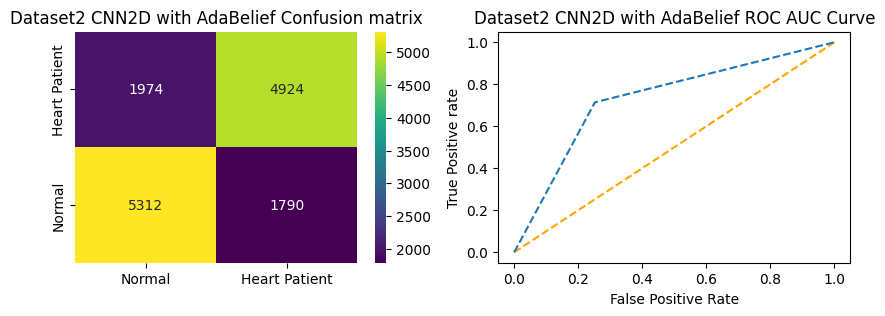

In [13]:
Y = dataset['cardio'].ravel()
dataset.drop(['id', 'cardio'], axis = 1,inplace=True)
X = dataset.values
scaler1 = StandardScaler()
X = scaler1.fit_transform(X)
X = np.reshape(X, (X.shape[0], X.shape[1], 1, 1))
Y = to_categorical(Y)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2)
#create CNN model object
ada_model2 = Sequential()
#adding CNN layer with 32 neurons for data optimizations and filteration 
ada_model2.add(Convolution2D(32, (1, 1), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
#max layer to collect relevant data from CNN layer and ignore irrelevant features
ada_model2.add(MaxPooling2D(pool_size = (1, 1)))
#defining another CNN layer for further data optimizations
ada_model2.add(Convolution2D(32, (1, 1), activation = 'relu'))
ada_model2.add(MaxPooling2D(pool_size = (1, 1)))
ada_model2.add(Flatten())
#defining output layer
ada_model2.add(Dense(units = 256, activation = 'relu'))
ada_model2.add(Dense(units = y_train.shape[1], activation='softmax'))
opt = tfa.optimizers.AdaBelief(learning_rate=0.0001)
#compile and train the model
ada_model2.compile(optimizer = opt, loss='categorical_crossentropy', metrics=['accuracy'])
if os.path.exists('model/cardio_ada_weights.hdf5') == False:
    model_check_point = ModelCheckpoint(filepath='model/cardio_ada_weights.hdf5', verbose = 1, save_best_only = True)
    hist = ada_model2.fit(X_train, y_train, epochs = 15, batch_size = 32, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/cardio_ada_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()
else:
    ada_model2.load_weights('model/cardio_ada_weights.hdf5')
#perfrom prediction on test data using CNN model    
predict = ada_model2.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("Dataset2 CNN2D with AdaBelief", y_test, predict)

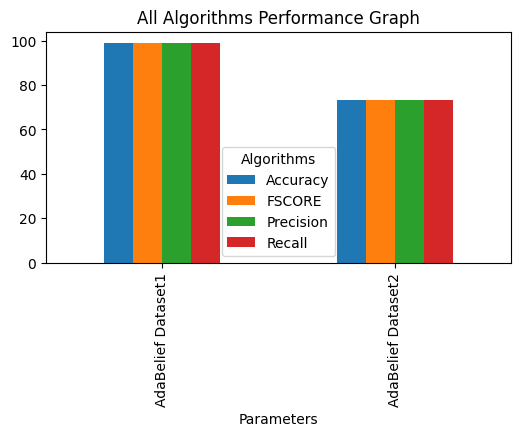

In [14]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['AdaBelief Dataset1','Accuracy',accuracy[0]],['AdaBelief Dataset1','Precision',precision[0]],['AdaBelief Dataset1','Recall',recall[0]],['AdaBelief Dataset1','FSCORE',fscore[0]],
                   ['AdaBelief Dataset2','Accuracy',accuracy[1]],['AdaBelief Dataset2','Precision',precision[1]],['AdaBelief Dataset2','Recall',recall[1]],['AdaBelief Dataset2','FSCORE',fscore[1]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot(index="Parameters", columns="Algorithms", values="Value").plot(kind='bar', figsize=(6, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [15]:
#display all algorithm performnace
algorithms = ['AdaBelief Dataset1', 'AdaBelief Dataset2']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,AdaBelief Dataset1,99.024390,99.029126,99.038462,99.024367
1,AdaBelief Dataset2,73.114286,73.123118,73.089421,73.093619


In [16]:
#=================flask code starts here
from flask import Flask, render_template, request, redirect, url_for, session,send_from_directory

In [17]:
app = Flask(__name__)
app.secret_key = 'welcome'

In [18]:
@app.route('/Predict', methods=['GET', 'POST'])
def predictView():
    return render_template('Predict.html', msg='')

@app.route('/index', methods=['GET', 'POST'])
def index():
    return render_template('index.html', msg='')

@app.route('/PredictAction', methods=['GET', 'POST'])
def PredictAction():
    if request.method == 'POST':
        ada_model1 = load_model('model/cleveland_ada_weights.hdf5')
        age = request.form['t1']
        gender = request.form['t2']
        chestpain = request.form['t3']
        bp = request.form['t4']
        cholesterol = request.form['t5']
        fasting = request.form['t6']
        ecg = request.form['t7']
        thalach = request.form['t8']
        exang = request.form['t9']
        peak = request.form['t10']
        slope = request.form['t11']
        ca = request.form['t12']
        thal = request.form['t13']
        data = []
        data.append([float(age),int(gender), int(chestpain), int(bp), int(cholesterol), int(fasting), int(ecg), int(thalach), 
                     int(exang), float(peak), int(slope), int(ca), int(thal)])
        data = np.asarray(data)
        data = scaler.transform(data)
        data = np.reshape(data, (data.shape[0], data.shape[1], 1, 1))
        predict = ada_model1.predict(data)#applying adabelief model to predict disease
        predict = np.argmax(predict)#getting label from binary predicted label
        predict = predict.ravel() 
        output = "<font size=4 color=green>Normal</font>"
        if predict == 1:
            output = "<font size=4 color=red>Heart Patient</font>"
        return render_template('Predict.html', msg="Predicted As "+output)


In [ ]:
if __name__ == '__main__':
    app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [22/Jun/2025 10:48:14] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [22/Jun/2025 10:48:14] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [22/Jun/2025 10:52:19] "GET /index HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2025 10:52:19] "GET /static/default.css HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2025 10:52:19] "GET /static/images/tra.jpg HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2025 10:52:19] "GET /static/images/back.jpg HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2025 10:52:19] "GET /static/images/img02.jpg HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2025 10:52:19] "GET /static/images/img05.jpg HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2025 10:52:19] "GET /static/images/img03.jpg HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2025 10:52:19] "GET /static/images/bg.jpg HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2025 10:52:56] "GET /index HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2025 10:52:56] "GET /static/default.css HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 10:52:5

1/1 [==============================] - 0s 81ms/step


127.0.0.1 - - [22/Jun/2025 10:54:50] "POST /PredictAction HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2025 10:54:50] "GET /static/default.css HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 10:54:50] "GET /static/images/tra.jpg HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 10:54:50] "GET /static/images/back.jpg HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 11:04:59] "GET /index HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2025 11:04:59] "GET /static/default.css HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 11:04:59] "GET /static/images/tra.jpg HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 11:04:59] "GET /static/images/back.jpg HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 11:04:59] "GET /static/images/img02.jpg HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 11:04:59] "GET /static/images/img05.jpg HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 11:04:59] "GET /static/images/img03.jpg HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 11:04:59] "GET /static/images/bg.jpg HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 11:05:01] "GET /Predict

1/1 [==============================] - 0s 134ms/step


127.0.0.1 - - [22/Jun/2025 11:06:40] "POST /PredictAction HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2025 11:06:40] "GET /static/default.css HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 11:06:40] "GET /static/images/tra.jpg HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 11:06:40] "GET /static/images/back.jpg HTTP/1.1" 304 -


1/1 [==============================] - 0s 142ms/step


127.0.0.1 - - [22/Jun/2025 11:07:19] "POST /PredictAction HTTP/1.1" 200 -
127.0.0.1 - - [22/Jun/2025 11:07:19] "GET /static/default.css HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 11:07:19] "GET /static/images/tra.jpg HTTP/1.1" 304 -
127.0.0.1 - - [22/Jun/2025 11:07:19] "GET /static/images/back.jpg HTTP/1.1" 304 -
